# 05. CNN — 합성곱 신경망의 원리와 기초

> **시리즈 위치**: 01. DNN 개념 → 02. DNN 훈련 → 03. RNN/LSTM 시계열 → 04. Transformer 시계열 → **05. CNN 개념**

이번 챕터에서는 이미지·시계열 같은 격자형(grid) 데이터에 강력한 효과를 보이는 **CNN(Convolutional Neural Network, 합성곱 신경망)** 을 다룹니다. 1D CNN(시계열·시퀀스) 과 2D CNN(이미지) 모두 학습하며, 가장 핵심적인 합성곱 연산의 동작 원리부터 풀링·채널 같은 부속 개념까지 단계별로 익힙니다.

## 학습 목표
- MLP(완전연결 신경망) 가 격자 데이터에 비효율적인 이유를 이해합니다
- 합성곱 연산의 직관과 수식을 손으로 직접 계산합니다
- 커널·스트라이드·패딩·채널이 출력 크기와 파라미터 수에 어떻게 영향을 주는지 익힙니다
- 풀링이 왜 필요한지, Max 와 Avg 의 차이가 무엇인지 시각으로 확인합니다
- 1D CNN 으로 합성 시계열을 분류하고, 2D CNN 으로 손글씨 숫자를 분류합니다
- 같은 데이터에서 CNN 과 MLP 의 파라미터 수·정확도를 비교합니다

## 목차

| Part | 주제 | 핵심 |
|------|------|------|
| 1 | 왜 CNN 이 필요한가요? | MLP 의 한계 + CNN 의 3가지 아이디어 |
| 2 | 합성곱(Convolution) 연산의 원리 | 1D 신호 위 슬라이딩 + 손계산 |
| 3 | 커널 · 스트라이드 · 패딩 · 채널 | 출력 크기 공식과 파라미터 수 |
| 4 | 풀링(Pooling) | Max vs Avg, 평행이동 둔감성 |
| 5 | 1D CNN — 시계열 분류 실습 | sin / 사각파 / 펄스 3-클래스 분류 |
| 6 | 2D CNN — 이미지 분류 실습 | sklearn digits (8×8) 10-클래스 분류 |
| 7 | CNN vs MLP 종합 비교 + 정리 | 같은 데이터에서 파라미터·정확도 비교 |


## 공통 설정

아래 셀을 한 번 실행하면 이후 모든 셀에서 한글 폰트와 라이브러리가 사용 가능합니다.

In [1]:
# [공통 설정] import / 한글 폰트 / 시드
import platform
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# 한글 폰트
sysname = platform.system()
if sysname == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif sysname == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 재현성을 위한 시드 고정
np.random.seed(42)
torch.manual_seed(42)

print('환경 확인 완료')
print(f'  - PyTorch: {torch.__version__}')
print(f'  - NumPy:   {np.__version__}')


환경 확인 완료
  - PyTorch: 2.11.0
  - NumPy:   2.4.4


---

## Part 1. 왜 CNN 이 필요한가요?

DNN 챕터에서 다룬 **MLP(다층 퍼셉트론)** 는 입력을 한 줄로 펼쳐(flatten) 모든 노드끼리 연결합니다. 이 방식은 정형 데이터에는 잘 맞지만, **이미지나 시계열처럼 격자(grid) 구조**가 있는 데이터에는 두 가지 큰 약점이 있습니다.

### MLP 의 한계

1. **파라미터 폭발**: 28×28 이미지를 단일 FC 레이어(은닉 128)로 받으면 `784 × 128 ≈ 10만` 개 가중치가 필요합니다. 입력이 커질수록 기하급수적으로 늘어납니다.
2. **위치 무시**: 같은 패턴이 1픽셀만 이동해도 MLP 는 완전히 다른 입력으로 인식합니다. 인접 픽셀이 관련 있다는 사실을 학습할 수 없습니다.

### CNN 의 3가지 핵심 아이디어

| 아이디어 | 설명 | 효과 |
|---------|------|------|
| ① **지역성**(Locality) | 작은 커널이 인접 영역만 봅니다 | 자연스러운 가정, 표현 효율 |
| ② **파라미터 공유** | 같은 커널이 모든 위치를 훑습니다 | 입력 크기와 무관한 적은 파라미터 |
| ③ **평행이동 불변성** | 패턴이 어디 있든 같은 필터로 감지 | 풀링과 결합되어 위치 변화에 둔감 |

<img src="images/05_cnn/cnn_motivation.png" width="900">

> 같은 정확도를 더 적은 파라미터로 달성합니다. 격자 구조 데이터에 압도적으로 효율적입니다.

### 실습 1-1. MLP 와 CNN 의 파라미터 수 비교

직접 모델을 만들어 파라미터 수가 얼마나 차이 나는지 확인해 봅니다.

In [2]:
# [시나리오] 28x28 이미지를 입력으로 받아 10개 클래스로 분류하는 모델을 비교합니다.
# 입력: 가상의 (1, 1, 28, 28) 이미지 1장
# 출력: 두 모델의 파라미터 수와 첫 번째 레이어 가중치 수

# (a) MLP — flatten 후 단일 FC
mlp_demo = nn.Sequential(
    nn.Flatten(),                  # (1, 784)
    nn.Linear(28*28, 128),         # 큰 가중치 행렬!
    nn.ReLU(),
    nn.Linear(128, 10),
)

# (b) CNN — 작은 커널만으로 충분
cnn_demo = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, padding=1),   # 가중치 = 3*3*1*8 + 8 = 80개
    nn.ReLU(),
    nn.MaxPool2d(2),                              # 학습 파라미터 0
    nn.Flatten(),
    nn.Linear(8 * 14 * 14, 10),
)

n_mlp = sum(p.numel() for p in mlp_demo.parameters())
n_cnn = sum(p.numel() for p in cnn_demo.parameters())

print(f'MLP 전체 파라미터:  {n_mlp:>8,} 개')
print(f'CNN 전체 파라미터:  {n_cnn:>8,} 개')
print(f'  -> CNN 이 MLP 의 {n_cnn / n_mlp * 100:.1f}% 수준입니다')
print()
print(f'  관찰 포인트: 첫 Conv 의 가중치 수 = 3*3*1*8 + 8 = 80 개입니다.')
print(f'  같은 크기의 첫 FC 가중치 수 = 784 * 128 = {784*128:,} 개와 비교해 보세요.')


MLP 전체 파라미터:   101,770 개
CNN 전체 파라미터:    15,770 개
  -> CNN 이 MLP 의 15.5% 수준입니다

  관찰 포인트: 첫 Conv 의 가중치 수 = 3*3*1*8 + 8 = 80 개입니다.
  같은 크기의 첫 FC 가중치 수 = 784 * 128 = 100,352 개와 비교해 보세요.


---

## Part 2. 합성곱(Convolution) 연산의 원리

합성곱은 **작은 커널이 입력 위를 슬라이딩하며 매 위치마다 내적(곱한 뒤 합)** 하는 연산입니다.

### 1D 합성곱 수식

길이 $L$ 의 입력 $x$ 에 크기 $K$ 의 커널 $w$ 를 적용하면, 출력 $y$ 의 각 원소는 다음과 같이 계산됩니다.

$$y[i] = \sum_{k=0}^{K-1} x[i+k] \cdot w[k] + b$$

여기서 $b$ 는 편향(bias)입니다.

### 출력 길이

스트라이드(stride) $S$, 패딩(padding) $P$ 을 고려한 일반 공식은:

$$L_{\text{out}} = \left\lfloor \frac{L_{\text{in}} + 2P - K}{S} \right\rfloor + 1$$

<img src="images/05_cnn/conv1d_step.png" width="900">

> **딥러닝의 "합성곱"은 사실 상관(cross-correlation)** 입니다. 신호처리의 정통 합성곱은 커널을 뒤집지만, 딥러닝에서는 뒤집지 않습니다. 어차피 가중치를 학습으로 결정하므로 차이는 없습니다.

### 실습 2-1. 1D 합성곱 손계산 확인

NumPy 로 직접 계산한 결과와 PyTorch `nn.functional.conv1d` 결과가 일치하는지 확인합니다.

In [17]:
# [시나리오] 길이 8의 신호 x 에 크기 3의 커널 w(미분 필터)를 적용합니다.
# 입력: 1차원 시퀀스 x = [1, 2, 3, 4, 5, 4, 3, 2]
# 커널: w = [1, 0, -1] (변화 감지 — 증가 구간이면 양수)
# 출력: 길이 6의 시퀀스 y, NumPy 손계산 vs PyTorch 결과

x = np.array([1, 2, 3, 4, 5, 4, 3, 2], dtype=np.float32)
w = np.array([-1, 0, 1], dtype=np.float32)   # 차이 검출 — 증가 구간 양수, 감소 구간 음수

# (a) NumPy 로 직접 슬라이딩하며 계산
K = len(w)
L_in = len(x)
L_out = L_in - K + 1
y_manual = np.zeros(L_out, dtype=np.float32)
for i in range(L_out):
    y_manual[i] = (x[i:i+K] * w).sum()

print('입력 x:', x.tolist())
print('커널 w:', w.tolist())
print()
print('단계별 계산:')
for i in range(L_out):
    win = x[i:i+K]
    print(f'  y[{i}] = ({win[0]:.0f}*{w[0]:.0f}) + ({win[1]:.0f}*{w[1]:.0f}) + ({win[2]:.0f}*{w[2]:.0f}) = {y_manual[i]:.0f}')
print()
print(f'NumPy 손계산 출력: {y_manual.tolist()}')

# (b) PyTorch 로 동일하게 계산
import torch.nn.functional as F
x_t = torch.from_numpy(x).view(1, 1, L_in)        # (배치, 채널, 길이)
w_t = torch.from_numpy(w).view(1, 1, K)           # (out_ch, in_ch, K)
y_torch = F.conv1d(x_t, w_t).flatten().numpy()
print(f'PyTorch 출력:    {y_torch.tolist()}')
print()
print(f'  관찰 포인트: 입력이 증가 구간(1->5)이면 양수, 감소 구간(5->2)이면 음수가 출력됩니다.')
print(f'  관찰 포인트: 손계산과 PyTorch 결과가 완전히 일치합니다.')


입력 x: [1.0, 2.0, 3.0, 4.0, 5.0, 4.0, 3.0, 2.0]
커널 w: [-1.0, 0.0, 1.0]

단계별 계산:
  y[0] = (1*-1) + (2*0) + (3*1) = 2
  y[1] = (2*-1) + (3*0) + (4*1) = 2
  y[2] = (3*-1) + (4*0) + (5*1) = 2
  y[3] = (4*-1) + (5*0) + (4*1) = 0
  y[4] = (5*-1) + (4*0) + (3*1) = -2
  y[5] = (4*-1) + (3*0) + (2*1) = -2

NumPy 손계산 출력: [2.0, 2.0, 2.0, 0.0, -2.0, -2.0]
PyTorch 출력:    [2.0, 2.0, 2.0, 0.0, -2.0, -2.0]

  관찰 포인트: 입력이 증가 구간(1->5)이면 양수, 감소 구간(5->2)이면 음수가 출력됩니다.
  관찰 포인트: 손계산과 PyTorch 결과가 완전히 일치합니다.


### 2D 합성곱

2D 합성곱은 1D 의 자연스러운 확장입니다. 커널이 가로·세로 두 방향으로 모두 슬라이딩합니다.

$$y[i, j] = \sum_{m=0}^{K-1} \sum_{n=0}^{K-1} x[i+m, j+n] \cdot w[m, n] + b$$

<img src="images/05_cnn/conv2d_step.png" width="900">

In [18]:
# [시나리오] 5x5 입력에 3x3 세로 엣지 검출 커널을 적용해 출력 3x3을 얻습니다.
# 입력: 5x5 정수 행렬 (가운데 열에서 값이 변하는 패턴)
# 커널: 세로 방향 변화에 반응하는 [1,0,-1] 패턴 (가로로 반복)
# 출력: 3x3 결과 행렬, NumPy 손계산 vs PyTorch 결과

X = np.array([
    [1, 2, 1, 0, 1],
    [0, 1, 2, 1, 0],
    [1, 2, 3, 2, 1],
    [0, 1, 2, 1, 0],
    [1, 0, 1, 2, 1],
], dtype=np.float32)

W = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1],
], dtype=np.float32)

H, W_w = X.shape
KH, KW = W.shape
OH, OW = H - KH + 1, W_w - KW + 1
Y_manual = np.zeros((OH, OW), dtype=np.float32)
for i in range(OH):
    for j in range(OW):
        Y_manual[i, j] = (X[i:i+KH, j:j+KW] * W).sum()

print('입력 X (5x5):')
print(X.astype(int))
print()
print('커널 W (3x3, 세로 엣지):')
print(W.astype(int))
print()
print('NumPy 손계산 출력 Y (3x3):')
print(Y_manual.astype(int))

X_t = torch.from_numpy(X).view(1, 1, H, W_w)
W_t = torch.from_numpy(W).view(1, 1, KH, KW)
Y_torch = F.conv2d(X_t, W_t).squeeze().numpy()
print()
print('PyTorch 출력 Y:')
print(Y_torch.astype(int))
print()
print(f'  해석: 가로 방향으로 화소 값이 변하면 큰 음수/양수, 평탄하면 0에 가까운 값이 나옵니다.')
print(f'  판단: NumPy 와 PyTorch 결과가 일치하면 손계산이 옳습니다.')


입력 X (5x5):
[[1 2 1 0 1]
 [0 1 2 1 0]
 [1 2 3 2 1]
 [0 1 2 1 0]
 [1 0 1 2 1]]

커널 W (3x3, 세로 엣지):
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

NumPy 손계산 출력 Y (3x3):
[[-4  2  4]
 [-6  0  6]
 [-4 -2  4]]

PyTorch 출력 Y:
[[-4  2  4]
 [-6  0  6]
 [-4 -2  4]]

  해석: 가로 방향으로 화소 값이 변하면 큰 음수/양수, 평탄하면 0에 가까운 값이 나옵니다.
  판단: NumPy 와 PyTorch 결과가 일치하면 손계산이 옳습니다.


---

## Part 3. 커널 · 스트라이드 · 패딩 · 채널

### 핵심 하이퍼파라미터

| 이름 | 기호 | 역할 |
|------|------|------|
| 커널 크기 | $K$ | 한 번에 보는 영역의 크기 (보통 3 또는 5) |
| 스트라이드 | $S$ | 커널이 한 번에 이동하는 칸 수 |
| 패딩 | $P$ | 입력 가장자리에 0을 채워 출력 크기 보존 |
| 입력 채널 | $C_{\text{in}}$ | 입력 텐서의 깊이 (RGB 면 3) |
| 출력 채널 | $C_{\text{out}}$ | 학습할 필터(특성 맵) 개수 |

### 출력 크기 공식

$$L_{\text{out}} = \left\lfloor \frac{L_{\text{in}} + 2P - K}{S} \right\rfloor + 1$$

같은 공식이 H, W 각각 따로 적용됩니다.

<img src="images/05_cnn/padding_stride.png" width="900">

### 채널(Channel) 개념

**채널**은 깊이 방향으로 쌓인 특성 맵의 수입니다. 컬러 이미지의 RGB 가 입력 채널 3, 학습할 필터의 수가 출력 채널입니다.

<img src="images/05_cnn/channel_concept.png" width="900">

### 합성곱 레이어의 파라미터 수

$$(\text{커널 크기})^d \cdot C_{\text{in}} \cdot C_{\text{out}} + C_{\text{out}}$$

- $d=1$: 1D, $d=2$: 2D
- 마지막 $+C_{\text{out}}$ 은 출력 채널마다 하나씩 있는 편향(bias)
- **입력 크기 H, W 와 무관**합니다 — MLP 와 결정적 차이

---

## Part 4. 풀링(Pooling)

**풀링**은 작은 영역을 하나의 대표값으로 압축하는 연산입니다. 학습 파라미터가 **0개**이며, 다음 두 가지 효과를 줍니다.

1. **다운샘플링**: 출력 크기를 줄여 연산량을 감소시킵니다
2. **평행이동 불변성**: 패턴이 미세하게 이동해도 결과가 거의 같습니다

### Max Pool vs Avg Pool

| 종류 | 동작 | 특징 |
|------|------|------|
| **Max Pool** | 영역의 최댓값 | 가장 강한 특성을 보존, 분류에 자주 사용 |
| **Avg Pool** | 영역의 평균값 | 부드러운 표현, 마지막 레이어 직전에 자주 사용 |

<img src="images/05_cnn/pooling.png" width="900">

In [7]:
# [시나리오] 4x4 입력에 2x2 풀링(stride 2)을 적용해 Max 와 Avg 결과를 비교합니다.
# 입력: 4x4 정수 행렬
# 출력: 2x2 Max Pool, 2x2 Avg Pool — 각 영역 대표값 확인

x = torch.tensor([
    [1, 3, 2, 4],
    [5, 6, 1, 2],
    [3, 2, 8, 5],
    [1, 0, 4, 3],
], dtype=torch.float32).view(1, 1, 4, 4)

max_pool = nn.MaxPool2d(2)
avg_pool = nn.AvgPool2d(2)
y_max = max_pool(x)
y_avg = avg_pool(x)

print('입력 (4x4):')
print(x.squeeze().int().numpy())
print()
print('Max Pool 결과 (2x2):')
print(y_max.squeeze().int().numpy())
print('  -> 각 2x2 영역에서 가장 큰 값을 골라옵니다')
print()
print('Avg Pool 결과 (2x2):')
print(y_avg.squeeze().numpy())
print('  -> 각 2x2 영역의 평균을 계산합니다')


입력 (4x4):
[[1 3 2 4]
 [5 6 1 2]
 [3 2 8 5]
 [1 0 4 3]]

Max Pool 결과 (2x2):
[[6 4]
 [3 8]]
  -> 각 2x2 영역에서 가장 큰 값을 골라옵니다

Avg Pool 결과 (2x2):
[[3.75 2.25]
 [1.5  5.  ]]
  -> 각 2x2 영역의 평균을 계산합니다


In [8]:
# [시나리오] 패턴을 한 칸 평행이동했을 때 Max Pool 결과가 얼마나 비슷한지 확인합니다.
# 입력: 같은 8x8 십자(cross) 패턴 — 원본 vs 1픽셀 우측 이동
# 출력: 풀링 후 두 결과의 코사인 유사도 — 평행이동 불변성 정량 확인

cross = torch.zeros(8, 8)
cross[3:5, :] = 1.0   # 가로선
cross[:, 3:5] = 1.0   # 세로선

cross_shift = torch.zeros(8, 8)
cross_shift[3:5, 1:] = 1.0
cross_shift[:, 4:6] = 1.0

x1 = cross.view(1, 1, 8, 8)
x2 = cross_shift.view(1, 1, 8, 8)

pool = nn.MaxPool2d(2)
p1 = pool(x1).flatten()
p2 = pool(x2).flatten()

# 풀링 전 유사도 vs 풀링 후 유사도
sim_before = torch.nn.functional.cosine_similarity(x1.flatten(), x2.flatten(), dim=0).item()
sim_after = torch.nn.functional.cosine_similarity(p1, p2, dim=0).item()

print(f'풀링 전 코사인 유사도: {sim_before:.4f}')
print(f'풀링 후 코사인 유사도: {sim_after:.4f}')
print()
print('  관찰 포인트: 풀링을 거치면 패턴이 1픽셀 이동해도 결과가 더 비슷해집니다.')
print('  관찰 포인트: 이것이 CNN 이 "위치 변화에 둔감"해지는 이유 중 하나입니다.')


풀링 전 코사인 유사도: 0.7412
풀링 후 코사인 유사도: 0.9129

  관찰 포인트: 풀링을 거치면 패턴이 1픽셀 이동해도 결과가 더 비슷해집니다.
  관찰 포인트: 이것이 CNN 이 "위치 변화에 둔감"해지는 이유 중 하나입니다.


---

## Part 5. 1D CNN — 시계열 분류 실습

이제 실제로 1D CNN 으로 **합성 시계열 신호를 3개 클래스로 분류**해 봅니다. 데이터는 다음 셀에서 생성합니다.

| 클래스 | 설명 | 예시 |
|--------|------|------|
| 0 (sine) | 부드러운 사인파 | 진동하는 주기 신호 |
| 1 (square) | 사각파 | 두 값을 오가는 신호 |
| 2 (spike) | 국소 펄스 | 평탄한 신호 + 1~2개 뾰족한 봉우리 |

신호 길이 64, 클래스당 300개씩 총 900개입니다.

X_train: (630, 1, 64),  y_train: (630,)
X_val:   (135, 1, 64),  y_val:   (135,)
X_test:  (135, 1, 64),  y_test:  (135,)
  각 클래스 개수 (train): [210 210 210]


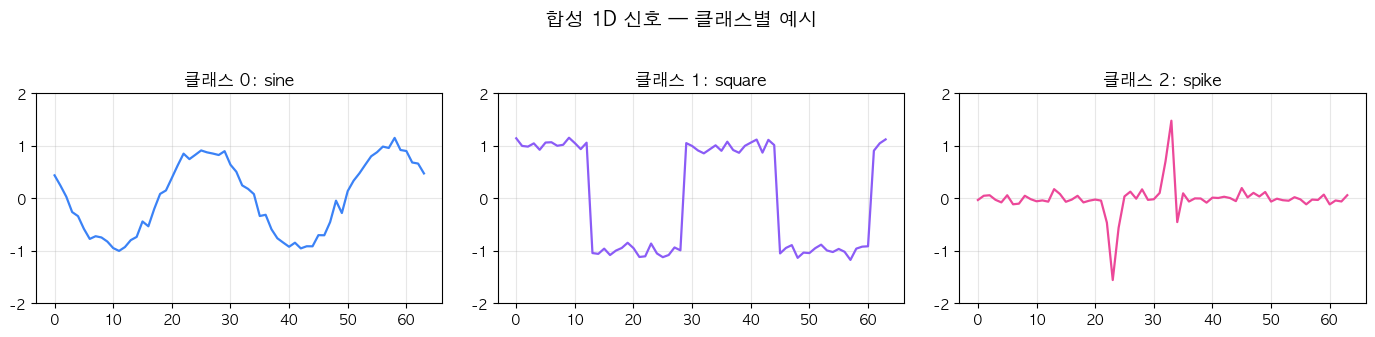

관찰 포인트: 세 클래스가 모양으로 명확히 구분됩니다 — 1D CNN이 잘 학습할 수 있는 구조입니다.


In [9]:
# [시나리오] 합성 1D 신호 3-클래스 데이터셋을 생성합니다.
# 입력: 클래스당 300개, 신호 길이 64
# 출력: X (900, 1, 64), y (900,), 학습/검증/테스트 분할

def make_signals(n_per_class=300, length=64, noise=0.08, seed=42):
    rng = np.random.default_rng(seed)
    X, y = [], []
    t = np.linspace(0, 4 * np.pi, length)
    for _ in range(n_per_class):
        # class 0: sine
        s = np.sin(t + rng.uniform(0, 2*np.pi)) + rng.normal(0, noise, length)
        X.append(s); y.append(0)
        # class 1: square
        s = np.sign(np.sin(t + rng.uniform(0, 2*np.pi))) + rng.normal(0, noise, length)
        X.append(s); y.append(1)
        # class 2: spike
        s = rng.normal(0, noise, length)
        n_spikes = rng.integers(1, 3)
        for _ in range(n_spikes):
            pos = rng.integers(5, length - 5)
            width = rng.integers(2, 5)
            for k in range(-width, width + 1):
                if 0 <= pos + k < length:
                    s[pos + k] += np.exp(-(k**2) / (width / 2)**2) * rng.choice([-1, 1]) * 1.5
        X.append(s); y.append(2)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)


X_sig, y_sig = make_signals()
# (N, length) -> (N, 1, length) — Conv1d 의 입력 형태
X_sig = X_sig[:, None, :]

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_sig, y_sig, test_size=0.3, random_state=42, stratify=y_sig)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp)

print(f'X_train: {X_train.shape},  y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape},  y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape},  y_test:  {y_test.shape}')
print(f'  각 클래스 개수 (train): {np.bincount(y_train)}')

# 시각화 — 클래스별 대표 신호 1개씩
# [시나리오] 위에서 만든 X_train 에서 각 클래스의 첫 신호를 그려 시각으로 확인합니다.
fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
labels = ['0: sine', '1: square', '2: spike']
colors = ['#3B82F6', '#8B5CF6', '#EC4899']
for c in range(3):
    idx = np.where(y_train == c)[0][0]
    axes[c].plot(X_train[idx, 0], color=colors[c], linewidth=1.6)
    axes[c].set_title(f'클래스 {labels[c]}', fontsize=12)
    axes[c].grid(alpha=0.3)
    axes[c].set_ylim(-2.0, 2.0)
plt.suptitle('합성 1D 신호 — 클래스별 예시', fontsize=14, y=1.04)
plt.tight_layout(); plt.show()
print('관찰 포인트: 세 클래스가 모양으로 명확히 구분됩니다 — 1D CNN이 잘 학습할 수 있는 구조입니다.')


### 1D CNN 모델 정의

`nn.Conv1d` 의 입력 형태는 **(배치, 채널, 길이)** 입니다.

In [19]:
# [시나리오] 작은 1D CNN 을 정의합니다.
# 구조: Conv1d(1->8) -> ReLU -> Pool -> Conv1d(8->16) -> ReLU -> Pool -> FC -> 3 클래스
# 입력: (batch, 1, 64)  /  출력: (batch, 3)

class CNN1D(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1,  out_channels=8,  kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(in_channels=8,  out_channels=16, kernel_size=5, padding=2)
        self.pool  = nn.MaxPool1d(kernel_size=2)
        self.fc    = nn.Linear(16 * 16, n_classes)   # 64 -> pool -> 32 -> pool -> 16

    def forward(self, x):
        x = torch.relu(self.conv1(x))     # (B, 8, 64)
        x = self.pool(x)                  # (B, 8, 32)
        x = torch.relu(self.conv2(x))     # (B, 16, 32)
        x = self.pool(x)                  # (B, 16, 16)
        x = x.flatten(1)                  # (B, 16*16=256)
        return self.fc(x)                 # (B, 3)


cnn1d_model = CNN1D()
print(cnn1d_model)
print()
print(f'총 파라미터 수: {sum(p.numel() for p in cnn1d_model.parameters()):,}')

# shape 추적 — 더미 입력으로 단계별 크기 확인
# [시나리오] 입력 텐서가 각 레이어를 지나며 어떻게 변하는지 출력합니다.
dummy = torch.zeros(2, 1, 64)
print(f'\nshape 추적 (배치 2):')
print(f'  입력          : {tuple(dummy.shape)}')
h = torch.relu(cnn1d_model.conv1(dummy));         print(f'  conv1 후      : {tuple(h.shape)}')
h = cnn1d_model.pool(h);                          print(f'  pool 후       : {tuple(h.shape)}')
h = torch.relu(cnn1d_model.conv2(h));             print(f'  conv2 후      : {tuple(h.shape)}')
h = cnn1d_model.pool(h);                          print(f'  pool 후       : {tuple(h.shape)}')
h = h.flatten(1);                                 print(f'  flatten 후    : {tuple(h.shape)}')
h = cnn1d_model.fc(h);                            print(f'  fc 후 (logits): {tuple(h.shape)}')


CNN1D(
  (conv1): Conv1d(1, 8, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv2): Conv1d(8, 16, kernel_size=(5,), stride=(1,), padding=(2,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)

총 파라미터 수: 1,475

shape 추적 (배치 2):
  입력          : (2, 1, 64)
  conv1 후      : (2, 8, 64)
  pool 후       : (2, 8, 32)
  conv2 후      : (2, 16, 32)
  pool 후       : (2, 16, 16)
  flatten 후    : (2, 256)
  fc 후 (logits): (2, 3)


  epoch  1/25  train_loss=1.0852  val_acc=47.4%
  epoch  5/25  train_loss=0.6229  val_acc=75.6%
  epoch 10/25  train_loss=0.2270  val_acc=100.0%
  epoch 15/25  train_loss=0.0618  val_acc=100.0%
  epoch 20/25  train_loss=0.0225  val_acc=100.0%
  epoch 25/25  train_loss=0.0100  val_acc=100.0%

최종 검증 정확도: 100.0%
테스트 정확도:    100.0%
  판단: 정확도 100% — 1D CNN 이 시계열 패턴을 잘 학습했습니다.


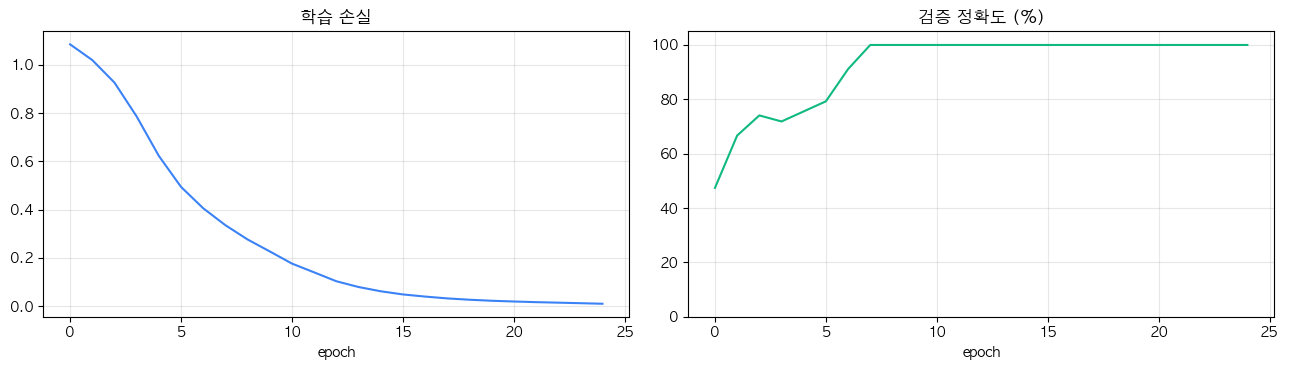

관찰 포인트: 손실은 안정적으로 감소하고, 검증 정확도는 빠르게 상승해 안정합니다.


In [11]:
# [시나리오] 위 1D CNN 을 학습/평가합니다.
# 입력: 학습셋 (630, 1, 64), 검증셋 (135, 1, 64)
# 출력: epoch별 loss, 최종 검증 정확도

# 텐서 변환
X_train_t = torch.from_numpy(X_train); y_train_t = torch.from_numpy(y_train)
X_val_t   = torch.from_numpy(X_val);   y_val_t   = torch.from_numpy(y_val)
X_test_t  = torch.from_numpy(X_test);  y_test_t  = torch.from_numpy(y_test)

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

torch.manual_seed(42)
model = CNN1D()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 25
history = {'train_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * xb.size(0)
    avg_loss = total_loss / len(train_ds)

    model.eval()
    with torch.no_grad():
        val_acc = (model(X_val_t).argmax(1) == y_val_t).float().mean().item()
    history['train_loss'].append(avg_loss)
    history['val_acc'].append(val_acc)
    if epoch % 5 == 0 or epoch == 1:
        print(f'  epoch {epoch:>2}/{EPOCHS}  train_loss={avg_loss:.4f}  val_acc={val_acc*100:.1f}%')

with torch.no_grad():
    test_acc = (model(X_test_t).argmax(1) == y_test_t).float().mean().item()
print(f'\n최종 검증 정확도: {history["val_acc"][-1]*100:.1f}%')
print(f'테스트 정확도:    {test_acc*100:.1f}%')
print(f'  판단: 정확도 {test_acc*100:.0f}% — 1D CNN 이 시계열 패턴을 잘 학습했습니다.')

# 학습 곡선 시각화
# [시나리오] history 의 train_loss 와 val_acc 를 두 패널로 그립니다.
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].plot(history['train_loss'], color='#3B82F6'); axes[0].set_title('학습 손실')
axes[0].set_xlabel('epoch'); axes[0].grid(alpha=0.3)
axes[1].plot(np.array(history['val_acc']) * 100, color='#10B981'); axes[1].set_title('검증 정확도 (%)')
axes[1].set_xlabel('epoch'); axes[1].grid(alpha=0.3); axes[1].set_ylim(0, 105)
plt.tight_layout(); plt.show()
print('관찰 포인트: 손실은 안정적으로 감소하고, 검증 정확도는 빠르게 상승해 안정합니다.')


---

## Part 6. 2D CNN — 이미지 분류 실습

이제 sklearn 의 **`load_digits()`** 데이터셋(8×8 grayscale 손글씨 숫자, 10 클래스, 1797개)을 2D CNN 으로 분류합니다.

> **데이터셋 스펙**: 1797장의 8×8 흑백 이미지, 픽셀값 0~16 (학습 시 16으로 나누어 0~1 정규화), 10개 클래스(숫자 0~9).

X_train: (1257, 1, 8, 8),  y_train: (1257,)
X_val:   (270, 1, 8, 8),  y_val:   (270,)
X_test:  (270, 1, 8, 8),  y_test:  (270,)
클래스 분포(train): [124 127 124 128 127 127 127 125 122 126]


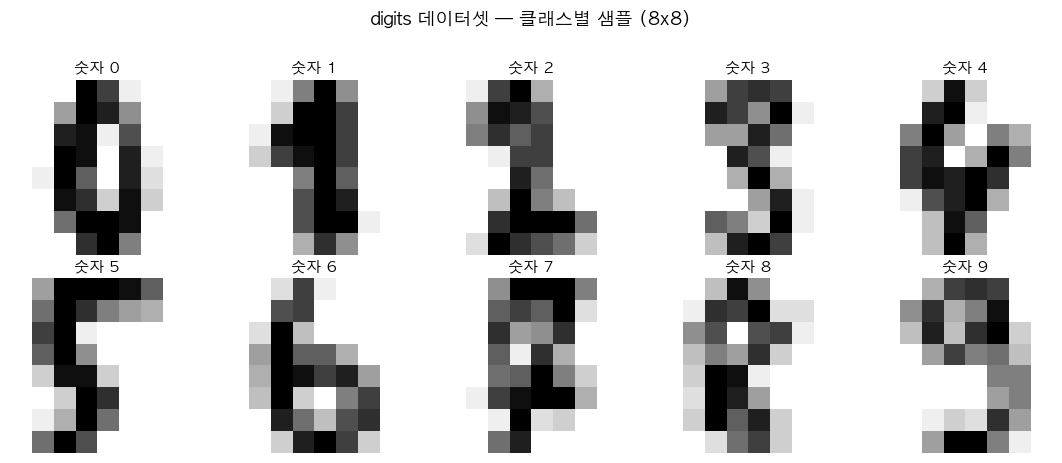

관찰 포인트: 8x8 저해상도라도 숫자 형태가 충분히 구별됩니다.


In [12]:
# [시나리오] sklearn load_digits 데이터를 로드해 (N, 1, 8, 8) 형태로 변환합니다.
# 입력: load_digits() — 1797장
# 출력: 학습/검증/테스트 분할 + 시각 확인

digits = load_digits()
X_img = digits.images.astype(np.float32) / 16.0   # (1797, 8, 8) → 0~1 정규화
y_img = digits.target.astype(np.int64)

# Conv2d 입력 형태로 채널 차원 추가: (N, 1, 8, 8)
X_img = X_img[:, None, :, :]

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_img, y_img, test_size=0.3, random_state=42, stratify=y_img)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp)

print(f'X_train: {X_train.shape},  y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape},  y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape},  y_test:  {y_test.shape}')
print(f'클래스 분포(train): {np.bincount(y_train)}')

# 시각 확인 — 각 클래스 1장씩
# [시나리오] 학습셋에서 0~9 숫자 각각 첫 이미지를 그려 데이터 모양을 확인합니다.
fig, axes = plt.subplots(2, 5, figsize=(11, 4.5))
for c in range(10):
    ax = axes[c // 5, c % 5]
    idx = np.where(y_train == c)[0][0]
    ax.imshow(X_train[idx, 0], cmap='gray_r')
    ax.set_title(f'숫자 {c}', fontsize=11)
    ax.axis('off')
plt.suptitle('digits 데이터셋 — 클래스별 샘플 (8x8)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
print('관찰 포인트: 8x8 저해상도라도 숫자 형태가 충분히 구별됩니다.')


### 2D CNN 모델 정의

`nn.Conv2d` 의 입력 형태는 **(배치, 채널, H, W)** 입니다.

In [13]:
# [시나리오] 작은 2D CNN 을 정의하고 shape 변화를 추적합니다.
# 구조: Conv2d(1->8, 3x3) -> Pool -> Conv2d(8->16, 3x3) -> Pool -> FC -> 10
# 입력: (batch, 1, 8, 8)  /  출력: (batch, 10)

class CNN2D(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1,  out_channels=8,  kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=8,  out_channels=16, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(kernel_size=2)
        self.fc    = nn.Linear(16 * 2 * 2, n_classes)

    def forward(self, x):
        x = torch.relu(self.conv1(x))     # (B, 8, 8, 8)
        x = self.pool(x)                  # (B, 8, 4, 4)
        x = torch.relu(self.conv2(x))     # (B, 16, 4, 4)
        x = self.pool(x)                  # (B, 16, 2, 2)
        x = x.flatten(1)                  # (B, 64)
        return self.fc(x)                 # (B, 10)


cnn2d_model = CNN2D()
print(cnn2d_model)
print()
print(f'총 파라미터 수: {sum(p.numel() for p in cnn2d_model.parameters()):,}')

# shape 추적
# [시나리오] 더미 (2, 1, 8, 8) 텐서로 각 레이어 통과 후 크기를 확인합니다.
dummy = torch.zeros(2, 1, 8, 8)
print(f'\nshape 추적 (배치 2):')
print(f'  입력          : {tuple(dummy.shape)}')
h = torch.relu(cnn2d_model.conv1(dummy));        print(f'  conv1 후      : {tuple(h.shape)}')
h = cnn2d_model.pool(h);                         print(f'  pool 후       : {tuple(h.shape)}')
h = torch.relu(cnn2d_model.conv2(h));            print(f'  conv2 후      : {tuple(h.shape)}')
h = cnn2d_model.pool(h);                         print(f'  pool 후       : {tuple(h.shape)}')
h = h.flatten(1);                                print(f'  flatten 후    : {tuple(h.shape)}')
h = cnn2d_model.fc(h);                           print(f'  fc 후 (logits): {tuple(h.shape)}')


CNN2D(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=64, out_features=10, bias=True)
)

총 파라미터 수: 1,898

shape 추적 (배치 2):
  입력          : (2, 1, 8, 8)
  conv1 후      : (2, 8, 8, 8)
  pool 후       : (2, 8, 4, 4)
  conv2 후      : (2, 16, 4, 4)
  pool 후       : (2, 16, 2, 2)
  flatten 후    : (2, 64)
  fc 후 (logits): (2, 10)


In [14]:
# [시나리오] 2D CNN 을 학습합니다.
# 입력: 학습 (1257, 1, 8, 8), 검증 (270, 1, 8, 8)
# 출력: epoch별 loss/val_acc, 최종 검증·테스트 정확도

X_train_t = torch.from_numpy(X_train); y_train_t = torch.from_numpy(y_train)
X_val_t   = torch.from_numpy(X_val);   y_val_t   = torch.from_numpy(y_val)
X_test_t  = torch.from_numpy(X_test);  y_test_t  = torch.from_numpy(y_test)

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

torch.manual_seed(42)
cnn = CNN2D()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)

EPOCHS = 40
history_cnn = {'train_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    cnn.train()
    total = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad(); loss = criterion(cnn(xb), yb); loss.backward(); optimizer.step()
        total += loss.item() * xb.size(0)
    avg = total / len(train_ds)

    cnn.eval()
    with torch.no_grad():
        v_acc = (cnn(X_val_t).argmax(1) == y_val_t).float().mean().item()
    history_cnn['train_loss'].append(avg)
    history_cnn['val_acc'].append(v_acc)
    if epoch % 10 == 0 or epoch == 1:
        print(f'  epoch {epoch:>2}/{EPOCHS}  train_loss={avg:.4f}  val_acc={v_acc*100:.1f}%')

with torch.no_grad():
    cnn_test_acc = (cnn(X_test_t).argmax(1) == y_test_t).float().mean().item()
n_cnn_params = sum(p.numel() for p in cnn.parameters())
print(f'\n2D CNN 최종 검증 정확도: {history_cnn["val_acc"][-1]*100:.1f}%')
print(f'2D CNN 테스트 정확도:    {cnn_test_acc*100:.1f}%')
print(f'2D CNN 파라미터 수:      {n_cnn_params:,}')


  epoch  1/40  train_loss=2.2860  val_acc=34.4%
  epoch 10/40  train_loss=0.6639  val_acc=86.7%
  epoch 20/40  train_loss=0.2318  val_acc=93.7%
  epoch 30/40  train_loss=0.1418  val_acc=95.2%
  epoch 40/40  train_loss=0.0981  val_acc=96.7%

2D CNN 최종 검증 정확도: 96.7%
2D CNN 테스트 정확도:    95.9%
2D CNN 파라미터 수:      1,898


---

## 핵심 정리

### 개념 요약표

| 개념 | 핵심 한 줄 |
|------|-----------|
| **합성곱(Convolution)** | 커널이 입력 위를 슬라이딩하며 매 위치마다 내적(곱한 뒤 합)합니다 |
| **커널(Kernel)** | 학습 가능한 작은 가중치 행렬, 보통 3 또는 5 |
| **스트라이드(Stride)** | 커널이 한 번에 이동하는 칸 수, 클수록 출력이 작아집니다 |
| **패딩(Padding)** | 가장자리에 0을 채워 출력 크기를 보존합니다 |
| **채널(Channel)** | 깊이 방향으로 쌓인 특성 맵의 수, RGB 면 입력 채널 3 |
| **풀링(Pooling)** | 작은 영역을 대표값(최대/평균)으로 압축, 학습 파라미터 0 |
| **평행이동 불변성** | 패턴이 위치를 옮겨도 같은 클래스로 인식하는 성질 |
| **출력 크기 공식** | $L_{out} = \lfloor (L_{in} + 2P - K) / S \rfloor + 1$ |
| **Conv 파라미터 수** | $K^d \cdot C_{in} \cdot C_{out} + C_{out}$ — 입력 크기와 무관합니다 |

### 핵심 코드 정리표

| 코드 | 역할 |
|------|------|
| `nn.Conv1d(in, out, kernel_size, padding, stride)` | 1D 합성곱 (시계열·시퀀스) |
| `nn.Conv2d(in, out, kernel_size, padding, stride)` | 2D 합성곱 (이미지) |
| `nn.MaxPool1d(2)` / `nn.MaxPool2d(2)` | 최대값 풀링 (다운샘플링) |
| `nn.AvgPool1d(2)` / `nn.AvgPool2d(2)` | 평균 풀링 |
| `x.flatten(1)` | 배치 차원 유지하고 나머지 차원 펼치기 |

### 흔한 오해

- ❌ "필터를 사람이 정한다" → ✅ 학습으로 자동 결정됩니다
- ❌ "CNN 은 이미지 전용이다" → ✅ 1D 는 시계열·텍스트, 2D 는 이미지, 3D 는 영상에 사용합니다
- ❌ "풀링 == 무조건 정보 손실" → ✅ 평행이동 불변성·연산량 절감 이점이 더 큽니다
